In [57]:
from dotenv import load_dotenv
load_dotenv()

True

In [58]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str # 공제액 
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산

graph_builder = StateGraph(AgentState)

In [59]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [60]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [61]:
from langchain_openai import ChatOpenAI
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate


rag_prompt = hub.pull('rlm/rag-prompt')
llm = ChatOpenAI(model="gpt-4o")
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [62]:

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

tax_base_equation_promt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_promt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information': tax_base_retrieval_chain} | tax_base_equation_chain


def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    tax_base_equation = tax_base_equation_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation': tax_base_equation}

In [63]:
get_tax_base_equation({})


{'tax_base_equation': '과세표준 = 공시가격 × 공정시장가액비율 - 1세대 1주택자의 경우 11억 원 공제 - 1세대 2주택자의 경우 6억 원 공제'}

In [64]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [65]:
get_tax_deduction({})


{'tax_deduction': '1세대 1주택자의 경우 주택에 대한 종합부동산세 계산 시 공제금액은 12억 원입니다. 2주택 이하를 소유한 경우, 세율별로 과세표준은 따로 적용됩니다. 과세표준에서 해당 금액을 공제하고 세금을 계산하게 됩니다.'}

In [66]:
from langchain_community.tools import TavilySearchResults
from datetime import date

tavily_search_tool = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState):
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    context = tavily_search_tool.invoke(query)
    print({'context': context})
    tax_market_ratio_prompt_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    market_ratio = tax_market_ratio_prompt_chain.invoke({'context': context, 'query': query})
    return {'market_ratio': market_ratio}

In [67]:
get_market_ratio({})

{'context': [{'title': '[2026 공시가격] 李정부, 공시가 손질 착수...내년부터 상승 가능성', 'url': 'https://v.daum.net/v/20260317160802885', 'content': '부동산 업계에서는 공시가격이 재산세와 종합부동산세 등 보유세 산정의 기준이 되는 핵심 지표인 만큼, 공시가격 현실화율이 조정될 경우 보유세 변화는 불가피할 것으로 분석한다.\n\n현재 재산세는 1가구 1주택자를 기준으로 공정시장가액비율이 공시가격 3억원 초과 6억원 이하 구간은 44%, 6억원 초과 구간은 45%가 적용된다. 종합부동산세는 1가구 1주택 기준 기본공제 12억원과 공정시장가액비율 60%가 적용된다.\n\n이에 따라 공시가격이 상승하면 재산세와 종합부동산세 과세표준이 높아지면서 보유세 부담도 함께 증가하게 된다. 특히 고가 주택의 경우, 종합부동산세 과세 대상이 되는 경우가 많아 공시가격 변동에 따른 세금 영향이 상대적으로 크게 나타날 수 있다.\n\n서진형 광운대 부동산법무학과 교수는 "공시가격 현실화율이 90% 수준으로 상향될 경우 세 부담을 느낀 보유자들이 매물을 시장에 내놓으면서 일정 부분 공급 확대 효과를 기대할 수 있다"면서도 "다만 조세 부담이 급격히 늘어나면 임대료로 전가되는 등 부작용이 나타날 수 있는 만큼, 국민 수용성을 고려한 정교한 정책 운용이 필요하다"고 말했다.\n\n이재성 기자 ljs@newsway.co.kr\n\nCopyright © 뉴스웨이. 무단전재, 재배포, AI 학습 이용 금지\n\n### 이 시각 추천뉴스\n\n### 실시간 트렌드\n\n실시간 트렌드 데이터는 안정화 기간 중 베타(Beta) 서비스로 운영하며, 01:00~06:00에는 데이터 수집 규모와 이용률이 낮아 제한적으로 제공합니다.\n\n### 서비스 바로가기 [...] # 뉴스웨이\n\n## 경제\n\n### [2026 공시가격] 李정부, 공시가 손질 착수...내년부터 상승 가능성\n\n이 글자크기로 변경됩니다.\n\n(예시

{'market_ratio': '2026년 현재 주택 공시가격에 적용되는 공정시장가액비율은 60%입니다.'}

In [68]:
from langchain_core.prompts import PromptTemplate

tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
주어진 내용을 기반으로 과세표준을 계산해주세요

과세표준 계산 공식: {tax_base_equation}
공제금액: {tax_deduction}
공정시장가액비율: {market_ratio}"""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState):
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    tax_base_calculation_chain = (
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })
    print(f'tax_base == {tax_base}')
    return {'tax_base': tax_base}

In [69]:
initial_state = {
    'query': query,
    'tax_base_equation': '과세표준 = (공시가격 × 공정시장가액비율) - 종합부동산세 공제금액',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 1세대 1주택자의 공제금액은 12억 원입니다. 법인이나 법인으로 보는 단체의 경우는 6억 원, 그 외의 자는 9억 원이 공제됩니다.',
    'market_ratio': '공정시장가액비율은 2024년 기준으로 60%입니다.'
    
}

In [70]:
calculate_tax_base(initial_state)

tax_base == 주어진 정보에 따라 과세표준을 계산해보겠습니다. 

사용자는 총 3채의 주택을 보유하고 있으며, 각각의 공시가격은 다음과 같습니다:
- 5억 원짜리 집 1채
- 10억 원짜리 집 1채
- 20억 원짜리 집 1채

1. 총 공시가격 합산:
   - 총 공시가격 = 5억 + 10억 + 20억 = 35억 원

2. 공정시장가액비율 적용:
   - 공정시장가액비율 (2024년 기준) = 60%
   - 과세 대상 금액 = 35억 × 60% = 21억 원

3. 공제금액:
   - 사용자가 구체적으로 1세대 1주택자에 해당하는지 특별한 정보는 없기에 기본 공제 금액 9억 원을 적용했습니다.
   - 과세표준 = 21억 - 9억 = 12억 원

이렇게 계산된 과세표준은 12억 원입니다. 이 금액을 기반으로 해당 년도 종합부동산세율을 적용하여 최종 세금을 계산할 수 있습니다. 종합부동산세는 과세표준에 세율을 곱하여 산출된 금액입니다. 이를 위해 실제 세율표를 참조해야 합니다. 추가적인 세율 정보 없이 구체적인 세금 금액을 제공하기 어렵습니다.


{'tax_base': '주어진 정보에 따라 과세표준을 계산해보겠습니다. \n\n사용자는 총 3채의 주택을 보유하고 있으며, 각각의 공시가격은 다음과 같습니다:\n- 5억 원짜리 집 1채\n- 10억 원짜리 집 1채\n- 20억 원짜리 집 1채\n\n1. 총 공시가격 합산:\n   - 총 공시가격 = 5억 + 10억 + 20억 = 35억 원\n\n2. 공정시장가액비율 적용:\n   - 공정시장가액비율 (2024년 기준) = 60%\n   - 과세 대상 금액 = 35억 × 60% = 21억 원\n\n3. 공제금액:\n   - 사용자가 구체적으로 1세대 1주택자에 해당하는지 특별한 정보는 없기에 기본 공제 금액 9억 원을 적용했습니다.\n   - 과세표준 = 21억 - 9억 = 12억 원\n\n이렇게 계산된 과세표준은 12억 원입니다. 이 금액을 기반으로 해당 년도 종합부동산세율을 적용하여 최종 세금을 계산할 수 있습니다. 종합부동산세는 과세표준에 세율을 곱하여 산출된 금액입니다. 이를 위해 실제 세율표를 참조해야 합니다. 추가적인 세율 정보 없이 구체적인 세금 금액을 제공하기 어렵습니다.'}

In [71]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ("system", '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요

종합부동산세 세율:{context}'''),
    ("user", '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요

과세표준: {tax_base}
주택 수:{query}''')
])


def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    tax_rate_chain = (
        tax_rate_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_rate = tax_rate_chain.invoke({
        'context': context,
        'tax_base': tax_base,
        'query': query})
    print(f'tax_rate == {tax_rate}')
    return {'answer': tax_rate}

In [78]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [79]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [80]:
graph = graph_builder.compile()

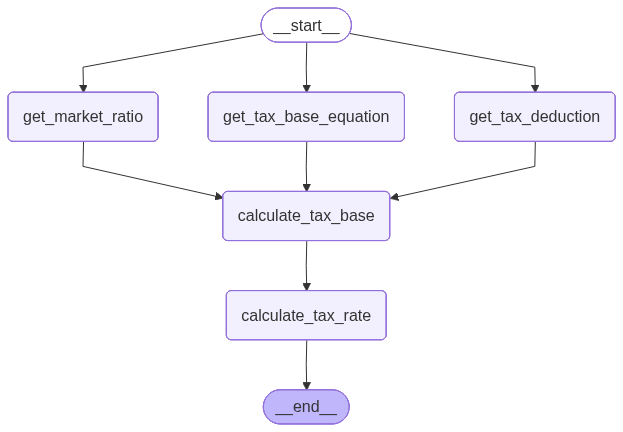

In [81]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [82]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'context': [{'title': '[2026 공시가격] 李정부, 공시가 손질 착수...내년부터 상승 가능성', 'url': 'https://v.daum.net/v/20260317160802885', 'content': '부동산 업계에서는 공시가격이 재산세와 종합부동산세 등 보유세 산정의 기준이 되는 핵심 지표인 만큼, 공시가격 현실화율이 조정될 경우 보유세 변화는 불가피할 것으로 분석한다.\n\n현재 재산세는 1가구 1주택자를 기준으로 공정시장가액비율이 공시가격 3억원 초과 6억원 이하 구간은 44%, 6억원 초과 구간은 45%가 적용된다. 종합부동산세는 1가구 1주택 기준 기본공제 12억원과 공정시장가액비율 60%가 적용된다.\n\n이에 따라 공시가격이 상승하면 재산세와 종합부동산세 과세표준이 높아지면서 보유세 부담도 함께 증가하게 된다. 특히 고가 주택의 경우, 종합부동산세 과세 대상이 되는 경우가 많아 공시가격 변동에 따른 세금 영향이 상대적으로 크게 나타날 수 있다.\n\n서진형 광운대 부동산법무학과 교수는 "공시가격 현실화율이 90% 수준으로 상향될 경우 세 부담을 느낀 보유자들이 매물을 시장에 내놓으면서 일정 부분 공급 확대 효과를 기대할 수 있다"면서도 "다만 조세 부담이 급격히 늘어나면 임대료로 전가되는 등 부작용이 나타날 수 있는 만큼, 국민 수용성을 고려한 정교한 정책 운용이 필요하다"고 말했다.\n\n이재성 기자 ljs@newsway.co.kr\n\nCopyright © 뉴스웨이. 무단전재, 재배포, AI 학습 이용 금지\n\n### 이 시각 추천뉴스\n\n### 실시간 트렌드\n\n실시간 트렌드 데이터는 안정화 기간 중 베타(Beta) 서비스로 운영하며, 01:00~06:00에는 데이터 수집 규모와 이용률이 낮아 제한적으로 제공합니다.\n\n### 서비스 바로가기 [...] # 뉴스웨이\n\n## 경제\n\n### [2026 공시가격] 李정부, 공시가 손질 착수...내년부터 상승 가능성\n\n이 글자크기로 변경됩니다.\n\n(예시

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주어진 정보에 따르면, 각 주택의 과세표준을 계산한 결과 총 과세표준이 -6억 원으로, 과세표준이 0 이하일 경우 종합부동산세는 부과되지 않습니다. 따라서 이러한 조건에서는 종합부동산세가 부과되지 않으며, 이에 따라 세금은 0원입니다.',
 'tax_base_equation': '과세표준 = (공시가격 × 공정시장가액비율) - 기본공제액',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시, 1세대 1주택자의 경우 공제금액은 12억 원입니다. 그 외의 경우 공제금액은 9억 원으로 설정되어 있습니다.',
 'market_ratio': '2026년 현재 주택에 적용되는 공정시장가액비율은 60%입니다.',
 'tax_base': '주어진 정보에 따라 각각의 주택과 전체 주택의 과세표준을 계산하겠습니다.\n\n1. 5억 원짜리 주택:\n- 공시가격: 5억 원\n- 공정시장가액비율: 60%\n- 공제금액: 9억 원 (1세대 1주택자에 해당하지 않음)\n\n과세표준 = (5억 × 0.6) - 9억 = 3억 - 9억 = -6억 원\n\n2. 10억 원짜리 주택:\n- 공시가격: 10억 원\n- 공정시장가액비율: 60%\n- 공제금액: 9억 원 (1세대 1주택자에 해당하지 않음)\n\n과세표준 = (10억 × 0.6) - 9억 = 6억 - 9억 = -3억 원\n\n3. 20억 원짜리 주택:\n- 공시가격: 20억 원\n- 공정시장가액비율: 60%\n- 공제금액: 9억 원 (1세대 1주택자에 해당하지 않음)\n\n과세표준 = (20억 × 0.6) - 9억 = 12억 - 9억 = 3억 원\n  \n총 과세표준 = (-6억) + (-3억) + 3억 = -6억 원\n\n과세표준이 0 이하인 경우, 세금은 부과되지 않습니다. 따라서, 현재 설정된 조건에 따르면 세금은 부과되지 않을 것입니다.'}